# Mean-Variance Portfolio Optimization

This notebook implements the core optimization framework of Modern Portfolio Theory.

Using the expected return vector $\mu$ and covariance matrix $\Sigma$ estimated from historical data, we construct portfolios and analyze the trade-off between expected return and risk.

This notebook focuses on:

1. loading expected return and covariance inputs  
2. generating random portfolios  
3. computing portfolio return and volatility  
4. visualizing the feasible set of portfolios  
5. preparing for efficient frontier analysis

The results of this notebook will provide the baseline portfolio optimization framework that will later be extended to regime-dependent market environments.

## Motivation

Investors face a trade-off between **expected return** and **risk**.

Modern Portfolio Theory models this trade-off using two key inputs:

- the vector of expected asset returns, $\mu$
- the covariance matrix of asset returns, $\Sigma$

For any portfolio with weight vector $w$:

- expected return is given by

$$
E[R_p] = w^\top \mu
$$

- portfolio variance is given by

$$
\mathrm{Var}(R_p) = w^\top \Sigma w
$$

The goal of portfolio optimization is to choose portfolio weights that produce the most desirable balance between expected return and risk.

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import json

# Create results directory for saving outputs
results_dir = Path("../results")
results_dir.mkdir(parents=True, exist_ok=True)

random_seed=123
np.random.seed(random_seed)

plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 12

pd.options.display.float_format = "{:.6f}".format

## Load Portfolio Inputs

This notebook uses the processed return data from Notebook 1 and the annualized covariance matrix from Notebook 2.

These two objects provide the key inputs for mean-variance portfolio analysis:

- expected annual returns
- annualized covariance matrix

In [2]:
returns = pd.read_csv("../data/processed/asset_returns.csv", index_col=0, parse_dates=True)
annual_cov_matrix = pd.read_csv("../data/processed/annual_cov_matrix.csv", index_col=0)

## Expected Annual Returns

We estimate expected returns using the sample mean of daily returns and annualize them using 252 trading days per year:

$$
\mu_{annual} = 252 \cdot \mu_{daily}
$$

These estimates will be used together with the covariance matrix to evaluate portfolios.

In [4]:
annual_mean_returns = returns.mean() * 252

annual_mean_returns

EFA   0.064177
GLD   0.090408
SPY   0.128637
TLT   0.028226
VNQ   0.084922
dtype: float64

In [5]:
# Align inputs
annual_cov_matrix = annual_cov_matrix.loc[annual_mean_returns.index, annual_mean_returns.index]

annual_cov_matrix

,EFA,GLD,SPY,TLT,VNQ
EFA,0.033925,0.004336,0.027214,-0.007964,0.026096
GLD,0.004336,0.026891,0.001482,0.005109,0.003729
SPY,0.027214,0.001482,0.029566,-0.007642,0.026444
TLT,-0.007964,0.005109,-0.007642,0.022621,-0.002891
VNQ,0.026096,0.003729,0.026444,-0.002891,0.042244


## Portfolio Return and Volatility Functions

For a portfolio with weight vector $w$, expected return and volatility are defined by:

$$
E[R_p] = w^\top \mu
$$

and

$$
\sigma_p = \sqrt{w^\top \Sigma w}
$$

These formulas allow us to evaluate any portfolio once the expected return vector and covariance matrix are known.

In [6]:
def calc_portfolio_return(weights, mean_returns):
    """
    Compute the expected portfolio return.
    """
    return weights.T @ mean_returns


def calc_portfolio_volatility(weights, cov_matrix):
    """
    Compute the portfolio volatility.
    """
    return np.sqrt(weights.T @ cov_matrix @ weights)


def portfolio_performance(weights, mean_returns, cov_matrix):
    """
    Compute both expected return and volatility for a portfolio.
    """
    port_return = calc_portfolio_return(weights, mean_returns)
    port_vol = calc_portfolio_volatility(weights, cov_matrix)
    return port_return, port_vol

## Example: Equal-Weight Portfolio

As a baseline, we evaluate a portfolio that assigns equal weight to each asset.

In [29]:
n_assets = len(annual_mean_returns)
equal_weights = np.ones(n_assets) / n_assets

equal_weights

array([0.2, 0.2, 0.2, 0.2, 0.2])

In [30]:
eq_return, eq_volatility = portfolio_performance(
    equal_weights,
    annual_mean_returns.values,
    annual_cov_matrix.values
)

print(f"Expected annual return: {eq_return:.2%}")
print(f"Annualized volatility: {eq_volatility:.2%}")

Expected annual return: 7.93%
Annualized volatility: 11.08%


### Interpretation

The equal-weight portfolio produces an estimated **expected annual return of approximately 7.93%**, with an **annualized volatility of about 11.08%**.

This result reflects a moderately diversified allocation across equities (SPY, EFA), real estate (VNQ), bonds (TLT), and gold (GLD). While the equity-heavy assets contribute most of the expected return, the inclusion of bonds and gold helps reduce overall portfolio volatility through diversification.

The equal-weight portfolio serves as a **baseline benchmark**. In the next sections, we will explore alternative portfolios that may achieve either:

- **higher expected returns for the same level of risk**, or  
- **lower risk for the same expected return**.

These portfolios form part of the **efficient frontier**, which represents the set of optimal portfolios under mean-variance theory.

---

## Random Portfolio Simulation

To visualize the range of possible portfolios, we simulate a large number (50,000) of random asset allocations.

Each random portfolio generates a unique combination of:

- expected return
- portfolio volatility

Plotting these portfolios reveals the **feasible region** of risk–return combinations achievable with the available assets.

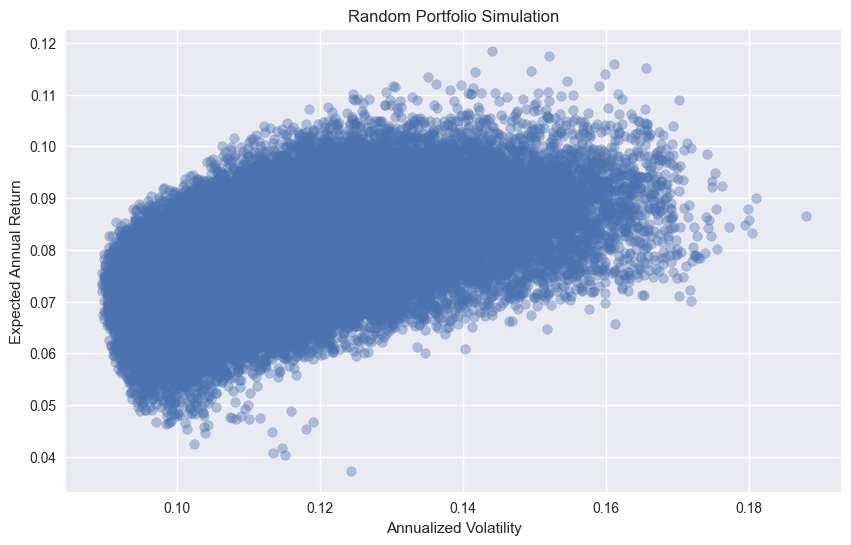

In [20]:
# Arrays to store results
n_portfolios = 50000
n_assets = len(annual_mean_returns)

sim_returns = np.zeros(n_portfolios)
sim_volatility = np.zeros(n_portfolios)
sim_weights = np.zeros((n_portfolios, n_assets))

# Generate random portfolios
for i in range(n_portfolios):
    weights = np.random.random(n_assets)
    weights /= np.sum(weights)

    sim_weights[i] = weights

    ret, vol = portfolio_performance(
        weights,
        annual_mean_returns.values,
        annual_cov_matrix.values
    )

    sim_returns[i] = ret
    sim_volatility[i] = vol

plt.figure(figsize=(10, 6))

plt.scatter(
    sim_volatility,
    sim_returns,
    alpha=0.4
)

plt.xlabel("Annualized Volatility")
plt.ylabel("Expected Annual Return")
plt.title("Random Portfolio Simulation")

plt.show()

### Interpretation

Each point in the plot represents a randomly generated portfolio with a different allocation across the available assets.

The horizontal axis measures **portfolio risk (annualized volatility)**, while the vertical axis measures **expected annual return**.

The cloud of points represents the **feasible region** of portfolios achievable with these assets. Portfolios toward the upper-left portion of the plot are more desirable because they offer higher returns for lower levels of risk.

The upper boundary of this region approximates the **efficient frontier**, which represents the set of portfolios that achieve the highest possible return for a given level of volatility.

### Approximate Efficient Frontier

The upper boundary of the feasible portfolio cloud represents the **efficient frontier**, which consists of portfolios delivering the highest expected return for each level of risk.

Because this notebook uses simulated portfolios rather than solving the optimization problem analytically for every target return, we approximate the efficient frontier by dividing the volatility range into small intervals and selecting the portfolio with the highest return in each interval.

In [52]:
frontier_df = pd.DataFrame({
    "volatility": sim_volatility,
    "return": sim_returns
})

# Sort portfolios by volatility
frontier_df = frontier_df.sort_values("volatility").reset_index(drop=True)

# Keep only points on the upper envelope
frontier_points_full = []
max_return_so_far = -np.inf

for _, row in frontier_df.iterrows():
    if row["return"] > max_return_so_far:
        frontier_points_full.append(row)
        max_return_so_far = row["return"]

frontier_points_full = pd.DataFrame(frontier_points_full)

frontier_points_full.head()

,volatility,return
0,0.089473,0.073220
2,0.089577,0.075537
5,0.089757,0.078238
8,0.089805,0.079201
55,0.090443,0.080579


## Identifying Optimal Portfolios

From the set of simulated portfolios, we can identify two important benchmarks:

- the **minimum variance portfolio**, which achieves the lowest possible volatility
- the **maximum Sharpe ratio portfolio**, which maximizes return per unit of risk

These portfolios represent key points on the efficient frontier.

### Sharpe Ratio

The Sharpe ratio measures the **risk-adjusted return** of a portfolio. It compares the portfolio’s expected excess return to the amount of risk taken to achieve that return.

Formally, the Sharpe ratio is defined as:

$$
S = \frac{E[R_p] - R_f}{\sigma_p}
$$

where:

- $E[R_p]$ is the expected portfolio return  
- $R_f$ is the risk-free rate  
- $\sigma_p$ is the portfolio volatility  

A higher Sharpe ratio indicates a **more efficient portfolio**, meaning the investor receives more return for each unit of risk taken.


### Risk-Free Rate

To compute Sharpe ratios, we incorporate a risk-free rate representing the return on a theoretically riskless asset.

In practice, short-term U.S. Treasury securities are commonly used as a proxy. For simplicity, we use an approximate current annual risk-free rate of **3.6%**, which is consistent with recent short-term Treasury yields.

This rate will be used when computing portfolio Sharpe ratios.

In [21]:
risk_free_rate = 0.036

# Sharpe ratios using excess returns
sharpe_ratios = (sim_returns - risk_free_rate) / sim_volatility

# Identify optimal portfolios
min_vol_idx = np.argmin(sim_volatility)
max_sharpe_idx = np.argmax(sharpe_ratios)

min_vol_return = sim_returns[min_vol_idx]
min_vol_vol = sim_volatility[min_vol_idx]

max_sharpe_return = sim_returns[max_sharpe_idx]
max_sharpe_vol = sim_volatility[max_sharpe_idx]

min_vol_weights = sim_weights[min_vol_idx]
max_sharpe_weights = sim_weights[max_sharpe_idx]

print("Minimum Variance Portfolio")
print(f"Return: {min_vol_return:.2%}")
print(f"Volatility: {min_vol_vol:.2%}")
print("Portfolio Weights:")
print(pd.Series(min_vol_weights, index=annual_mean_returns.index).map(lambda x: f"{x:.2%}"))

print()

print("Maximum Sharpe Portfolio")
print(f"Return: {max_sharpe_return:.2%}")
print(f"Volatility: {max_sharpe_vol:.2%}")
print(f"Sharpe Ratio: {sharpe_ratios[max_sharpe_idx]:.2f}")
print("Portfolio Weights:")
print(pd.Series(max_sharpe_weights, index=annual_mean_returns.index).map(lambda x: f"{x:.2%}"))

Minimum Variance Portfolio
Return: 7.32%
Volatility: 8.95%
Portfolio Weights:
EFA     5.38%
GLD    19.23%
SPY    29.96%
TLT    43.63%
VNQ     1.80%
dtype: str

Maximum Sharpe Portfolio
Return: 10.16%
Volatility: 10.80%
Sharpe Ratio: 0.61
Portfolio Weights:
EFA     0.01%
GLD    36.94%
SPY    49.52%
TLT    12.42%
VNQ     1.10%
dtype: str


### Optimal Portfolios

Two important portfolios were identified from the simulation:

**Minimum Variance Portfolio**
- Expected return: **7.32%**
- Volatility: **8.95%**

This portfolio minimizes overall portfolio risk. It achieves the lowest possible volatility among all simulated portfolios.

**Maximum Sharpe Ratio Portfolio**
- Expected return: **10.16%**
- Volatility: **10.80%**

This portfolio maximizes the Sharpe ratio, meaning it provides the **best return per unit of risk** given the assumed risk-free rate of **3.6%**. It represents the most efficient trade-off between risk and return among the simulated portfolios.

In practice, investors seeking **maximum risk-adjusted performance** would prefer the maximum Sharpe portfolio, while extremely risk-averse investors may prefer the minimum variance portfolio.

---

## Visualizing Optimal Portfolios

The simulated portfolios can be plotted in risk–return space to visualize the feasible region of portfolio allocations.

By coloring portfolios according to their Sharpe ratios, we can identify which areas of the feasible set provide stronger risk-adjusted performance.

We also highlight two important portfolios:

- the **minimum variance portfolio**
- the **maximum Sharpe ratio portfolio**

In [53]:
frontier_points = frontier_points_full[
    frontier_points_full["volatility"] >= min_vol_vol
].reset_index(drop=True)

frontier_points.head()

,volatility,return
0,0.089473,0.073220
1,0.089577,0.075537
2,0.089757,0.078238
3,0.089805,0.079201
4,0.090443,0.080579


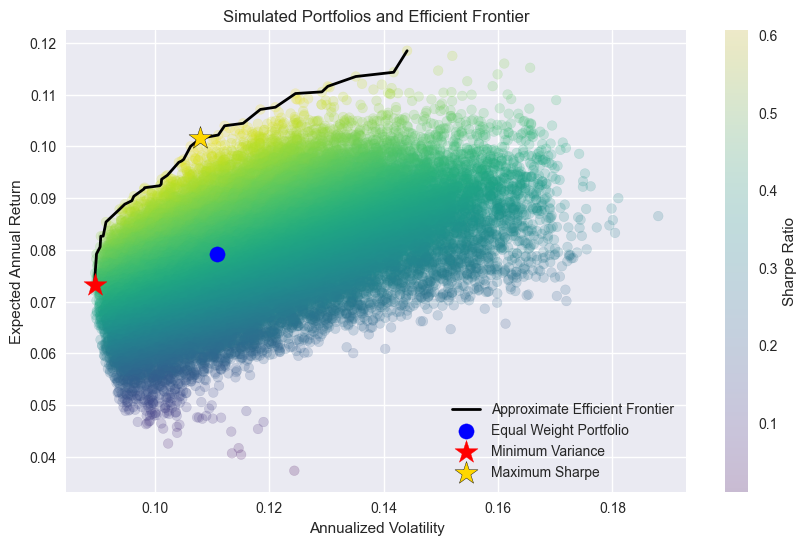

In [55]:
plt.figure(figsize=(10, 6))

# Portfolio cloud
scatter = plt.scatter(
    sim_volatility,
    sim_returns,
    c=sharpe_ratios,
    cmap="viridis",
    alpha=0.2,
    zorder=1
)

# Efficient frontier
plt.plot(
    frontier_points["volatility"],
    frontier_points["return"],
    color="black",
    linewidth=2,
    label="Approximate Efficient Frontier",
    zorder=2
)

# Equal-weight portfolio
plt.scatter(
    eq_volatility,
    eq_return,
    color="blue",
    s=120,
    label="Equal Weight Portfolio",
    zorder=3
)

# Minimum variance portfolio
plt.scatter(
    min_vol_vol,
    min_vol_return,
    color="red",
    marker="*",
    s=300,
    label="Minimum Variance",
    zorder=4
)

# Maximum Sharpe portfolio
plt.scatter(
    max_sharpe_vol,
    max_sharpe_return,
    color="gold",
    edgecolor="black",
    marker="*",
    s=300,
    label="Maximum Sharpe",
    zorder=5
)

plt.colorbar(scatter, label="Sharpe Ratio")
plt.xlabel("Annualized Volatility")
plt.ylabel("Expected Annual Return")
plt.title("Simulated Portfolios and Efficient Frontier")
plt.legend(loc="lower right")

plt.savefig(results_dir / "efficient_frontier.png", dpi=300, bbox_inches="tight")

plt.show()

### Interpretation

This figure summarizes the main results of the portfolio optimization analysis.

- Each point in the cloud represents a simulated portfolio generated from a different set of asset weights.
- The horizontal axis shows **annualized volatility**, which measures portfolio risk.
- The vertical axis shows **expected annual return**.
- The color of each point represents the **Sharpe ratio**, so portfolios with brighter colors deliver stronger risk-adjusted performance.

The black curve represents the **approximate efficient frontier**, which traces the set of portfolios that deliver the highest expected return for a given level of risk. Portfolios below this curve are inefficient because another portfolio exists with either:

- higher return for the same risk, or
- lower risk for the same return.

Three benchmark portfolios are highlighted:

- The **equal-weight portfolio** is shown in blue. It provides a simple baseline allocation, but it lies below the efficient frontier, which means it is not an efficient portfolio.
- The **minimum variance portfolio** is shown in red. It lies at the far-left end of the frontier and represents the lowest-risk allocation available in the simulated portfolio set.
- The **maximum Sharpe portfolio** is shown in gold. It lies along the upper portion of the frontier and provides the best trade-off between expected return and risk given the assumed risk-free rate.

This graph clearly illustrates the benefit of efficient portfolios over a naive equal-weight allocation. While the equal-weight portfolio is easy to construct, optimization identifies portfolios that achieve either **higher expected return for similar risk** or **lower risk for similar return**. That is the central insight of mean-variance portfolio theory.

### Optimal Portfolio Allocations

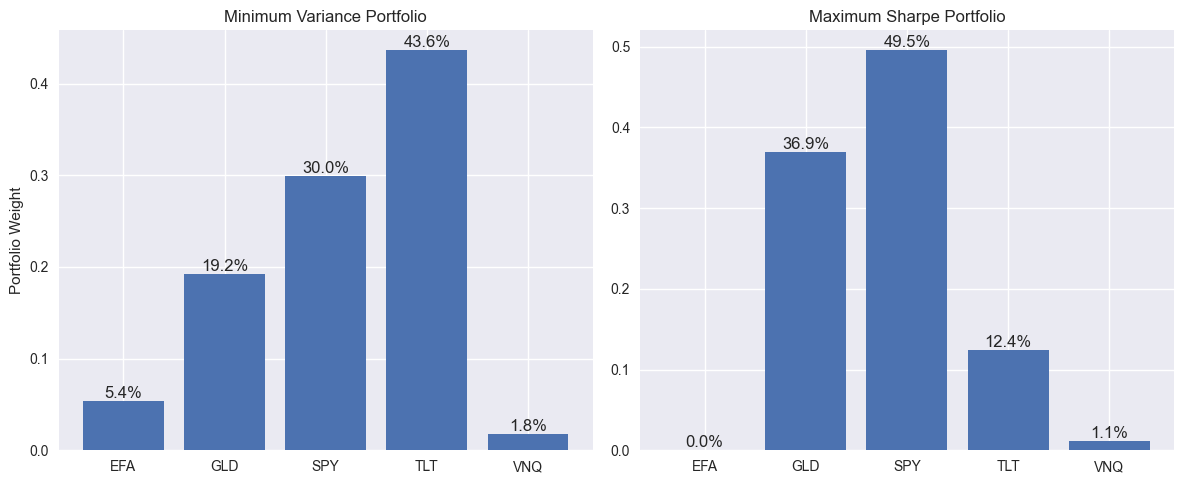

In [46]:
assets = annual_mean_returns.index

min_vol_series = pd.Series(min_vol_weights, index=assets)
max_sharpe_series = pd.Series(max_sharpe_weights, index=assets)

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Minimum variance plot
bars1 = axes[0].bar(min_vol_series.index, min_vol_series.values)
axes[0].set_title("Minimum Variance Portfolio")
axes[0].set_ylabel("Portfolio Weight")

for bar in bars1:
    height = bar.get_height()
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.1%}",
        ha="center",
        va="bottom"
    )

# Maximum Sharpe plot
bars2 = axes[1].bar(max_sharpe_series.index, max_sharpe_series.values)
axes[1].set_title("Maximum Sharpe Portfolio")

for bar in bars2:
    height = bar.get_height()
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.1%}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [56]:
# ---------------------------------------------------------
# Save results for downstream notebooks (regime modeling)
# ---------------------------------------------------------

# Assets list
assets = annual_mean_returns.index

# ---------------------------------------------------------
# Save optimal portfolio weights
# ---------------------------------------------------------

min_vol_series = pd.Series(min_vol_weights, index=assets, name="Min_Variance")
max_sharpe_series = pd.Series(max_sharpe_weights, index=assets, name="Max_Sharpe")

min_vol_series.to_csv(results_dir / "min_variance_weights.csv")
max_sharpe_series.to_csv(results_dir / "max_sharpe_weights.csv")

# Combined weights table (cleaner for later loading)
optimal_weights = pd.DataFrame({
    "Asset": assets,
    "Min_Variance": min_vol_weights,
    "Max_Sharpe": max_sharpe_weights
})

optimal_weights.to_csv(results_dir / "optimal_weights.csv", index=False)

# ---------------------------------------------------------
# Save efficient frontier points
# ---------------------------------------------------------

frontier_points.to_csv(
    results_dir / "efficient_frontier.csv",
    index=False
)

# ---------------------------------------------------------
# Save full simulation results (all portfolios)
# ---------------------------------------------------------

simulation_results = pd.DataFrame({
    "volatility": sim_volatility,
    "return": sim_returns,
    "sharpe_ratio": sharpe_ratios
})

simulation_results.to_csv(
    results_dir / "simulation_results.csv",
    index=False
)

# ---------------------------------------------------------
# Save summary statistics
# ---------------------------------------------------------

eq_sharpe = (eq_return - risk_free_rate) / eq_volatility
min_vol_sharpe = (min_vol_return - risk_free_rate) / min_vol_vol
max_sharpe_ratio = (max_sharpe_return - risk_free_rate) / max_sharpe_vol

summary = pd.DataFrame({
    "Portfolio": ["Equal Weight", "Minimum Variance", "Maximum Sharpe"],
    "Return": [eq_return, min_vol_return, max_sharpe_return],
    "Volatility": [eq_volatility, min_vol_vol, max_sharpe_vol],
    "Sharpe_Ratio": [eq_sharpe, min_vol_sharpe, max_sharpe_ratio]
})

summary.to_csv(
    results_dir / "portfolio_summary.csv",
    index=False
)

summary

,Portfolio,Return,Volatility,Sharpe_Ratio
0,Equal Weight,0.079274,0.110828,0.390462
1,Minimum Variance,0.073220,0.089473,0.415991
2,Maximum Sharpe,0.101552,0.107979,0.607075


In [59]:
metadata = {
    "risk_free_rate": risk_free_rate,
    "n_portfolios": n_portfolios,
    "random_seed": random_seed,
    "assets": list(assets)
}

with open(results_dir / "optimization_metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

In addition to portfolio outputs, a metadata file is saved to document the optimization settings used in the notebook. This improves reproducibility and makes it easier for downstream notebooks to load the results consistently.

---

## Conclusion

This notebook implemented a Monte Carlo simulation approach to portfolio optimization using modern portfolio theory.

Using historical return and covariance estimates, 50,000 random portfolios were generated and evaluated based on their expected return and volatility. This allowed visualization of the feasible set of portfolios and the approximate efficient frontier.

Two key portfolios were identified:

- The **minimum variance portfolio**, which minimizes total portfolio risk.
- The **maximum Sharpe ratio portfolio**, which provides the highest expected return per unit of risk given the assumed risk-free rate.

The results demonstrate that optimized portfolios on the efficient frontier provide superior risk–return trade-offs compared to a naive equal-weight allocation.

The optimal portfolio weights and efficient frontier points have been saved for use in later notebooks, where portfolio construction will be extended to incorporate **market regime modeling and dynamic asset allocation**.